# Initialisation

* `src()` works well in the previous workflow whereas the current call does not (with yellow wave under the functions which actually are called).
* `parameter issue`
  * JUN_5
      "_alpha"     :     12,
      "_beta"      :     0.02,
  * JUN_4
      "_alpha"     :     1,
      "_beta"      :     0.05,


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
RC_SIMULATOR = "ETHlib"
if RC_SIMULATOR not in sys.path:
    sys.path.insert(0, RC_SIMULATOR)

from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system

case = RCCase(
    year=2023,
    loc_json              = Path("_json/location_params.json"),
    geo_json              = Path("_json/geo_params.json"),
    default_json          = Path("_json/default_params.json"),
    epw_path              = Path("../src/_base/epw/ED-TMYx.2023.epw"),
    occupancy_profile_csv = Path("ETHlib/auxiliary/schedules_el_OFFICE.csv"),
    Zone=Zone,
    supply_system=supply_system,
    emission_system=emission_system,
)

case.occupancy_profile = (
    pd.read_csv(Path("_data/bldg_LoD.csv"), usecols=["D"])
      .rename(columns={"D": "People"})
      .iloc[:8760]
      .reset_index(drop=True)
)

In [3]:
meter_path = "_data/Metering_ISO.csv"

meter_daily = load_meter_heating(
    meter_path,
    "Main Heating",
    case.geometry["FLOOR_AREA"],
    "D",
)

meter_hourly = load_meter_heating(
    meter_path,
    "Main Heating",
    case.geometry["FLOOR_AREA"],
    "h",
)

Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00


# Test_1

In [4]:
start_date = "2023-01-23"
end_date = "2023-01-31"

In [5]:
result, eui, debug = run_model_case(
    case=case,
    sampled_params={},
    controller_mode="original",
)
debug_df = debug.get_debug_dataframe()
debug_df.index = result.index
sample = debug_df.loc[
    start_date:end_date,
    ["energy_demand", "t_air_free", "heating_setpoint", "t_out"],
]

In [6]:
print(sample)

                     energy_demand  t_air_free  heating_setpoint  t_out
2023-01-23 00:00:00   44114.336062   14.590936              15.0    3.7
2023-01-23 01:00:00   59187.211937   14.451168              15.0    3.9
2023-01-23 02:00:00   69186.702604   14.358445              15.0    4.3
2023-01-23 03:00:00   78607.070794   14.271091              15.0    4.5
2023-01-23 04:00:00   86595.318797   14.197018              15.0    4.4
...                            ...         ...               ...    ...
2023-01-31 19:00:00       0.000000   19.458145              15.0    4.3
2023-01-31 20:00:00       0.000000   19.099228              15.0    4.4
2023-01-31 21:00:00       0.000000   18.682374              15.0    4.4
2023-01-31 22:00:00       0.000000   18.288083              15.0    4.4
2023-01-31 23:00:00       0.000000   17.910246              15.0    4.4

[216 rows x 4 columns]


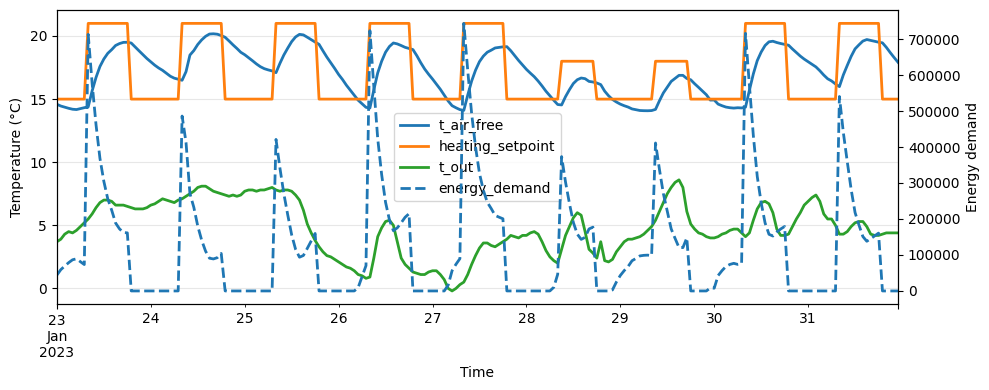

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 4))
sample[['t_air_free', 'heating_setpoint', 't_out']].plot(
    ax=ax1,
    linewidth=2
)
ax1.set_ylabel('Temperature (°C)')
ax1.set_xlabel('Time')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
sample['energy_demand'].plot(
    ax=ax2,
    linestyle='--',
    linewidth=2,
    label='energy_demand'
)
ax2.set_ylabel('Energy demand')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.tight_layout()
plt.show()

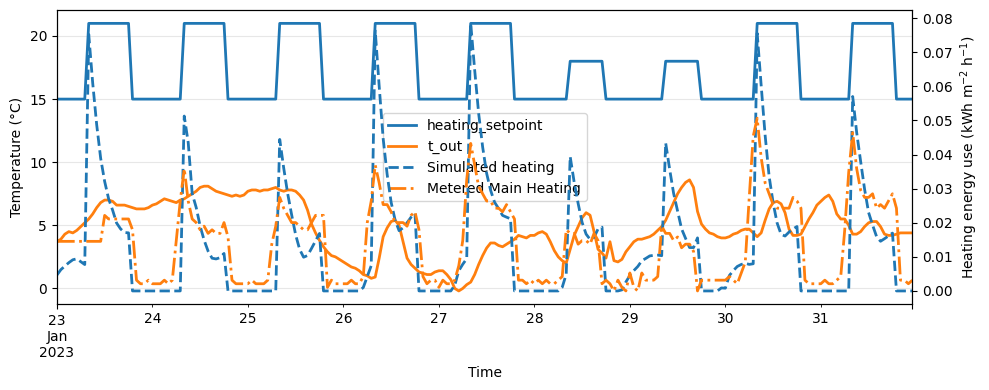

In [8]:
import matplotlib.pyplot as plt
sample = sample.copy()
sample["sim_heating_energy"] = result.loc[sample.index, "HeatingEnergy"]
meter_ref = meter_hourly.loc[sample.index.min():sample.index.max()]

fig, ax1 = plt.subplots(figsize=(10, 4))

sample[["heating_setpoint", "t_out"]].plot(
    ax=ax1,
    linewidth=2,
)

ax1.set_ylabel("Temperature (°C)")
ax1.set_xlabel("Time")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

sample["sim_heating_energy"].plot(
    ax=ax2,
    linestyle="--",
    linewidth=2,
    label="Simulated heating",
)

meter_ref.plot(
    ax=ax2,
    linestyle="-.",
    linewidth=2,
    label="Metered Main Heating",
)

ax2.set_ylabel(r"Heating energy use (kWh m$^{-2}$ h$^{-1}$)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
)

plt.tight_layout()
plt.show()

# Test_2

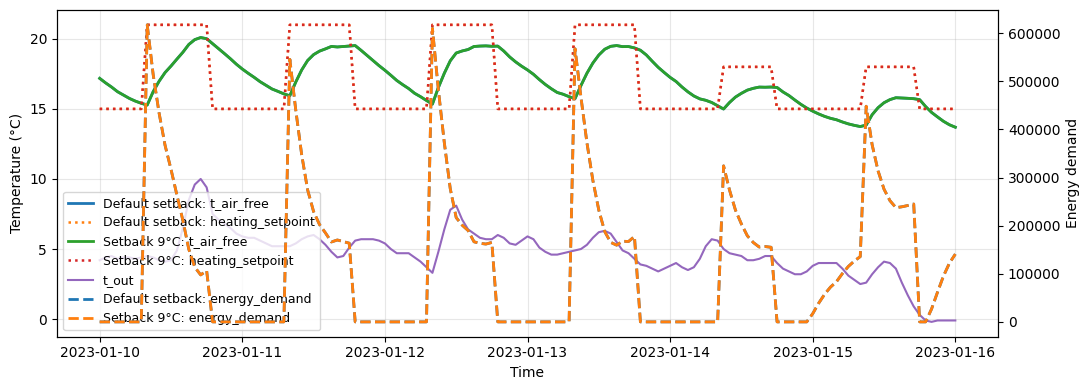

In [9]:
import matplotlib.pyplot as plt

# -------------------------
# Contrast setup
# -------------------------
contrast_cases = {
    "Default setback": {},
    "Setback 9°C": {
        "t_setback_heating": 15,
    },
}

start = "2023-01-10 00:00"
end = "2023-01-16 00:00"

debug_cols = [
    "energy_demand",
    "t_air_free",
    "heating_setpoint",
    "t_out",
]

samples = {}

# -------------------------
# Run contrast cases
# -------------------------
for case_name, sampled_params in contrast_cases.items():

    result, eui, debug = run_model_case(
        case=case,
        sampled_params=sampled_params,
        controller_mode="original",
    )

    debug_df = debug.get_debug_dataframe()
    debug_df.index = result.index

    samples[case_name] = debug_df.loc[start:end, debug_cols].copy()

# -------------------------
# Plot contrast
# -------------------------
fig, ax1 = plt.subplots(figsize=(11, 4))

for case_name, sample in samples.items():
    ax1.plot(
        sample.index,
        sample["t_air_free"],
        linewidth=2,
        label=f"{case_name}: t_air_free",
    )

    ax1.plot(
        sample.index,
        sample["heating_setpoint"],
        linewidth=1.8,
        linestyle=":",
        label=f"{case_name}: heating_setpoint",
    )

# outdoor temperature only once
ax1.plot(
    samples["Default setback"].index,
    samples["Default setback"]["t_out"],
    linewidth=1.5,
    label="t_out",
)

ax1.set_ylabel("Temperature (°C)")
ax1.set_xlabel("Time")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

for case_name, sample in samples.items():
    ax2.plot(
        sample.index,
        sample["energy_demand"],
        linestyle="--",
        linewidth=2,
        label=f"{case_name}: energy_demand",
    )

ax2.set_ylabel("Energy demand")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    fontsize=9,
)

plt.tight_layout()
plt.show()